Baseline

In [4]:
import json
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Download risorse NLTK (solo la prima volta)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download('punkt_tab')

STOP_WORDS = set(stopwords.words("english"))

def load_articles_from_json(path):
    """
    Legge un file JSON e restituisce una lista di articoli
    con category, title e content, filtrando quelli con categoria vuota.
    """
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    articles = []

    for item in data:
        article_category = item.get("category", "").lower() # Convert to lowercase for consistency
        # Only include articles with a non-empty category
        if article_category and article_category in ["sport", "business", "arts"]:
            article = {
                "category": article_category,
                "title": item.get("title", ""),
                "content": item.get("content", "")
            }
            articles.append(article)

    return articles

def get_common_token(all_tokens_list, max_token=20):
  # Appiattiamo la lista di liste in una singola lista di token
  flattened_tokens = [token for sublist in all_tokens_list for token in sublist]

  token_counts = Counter(flattened_tokens)

  # prendi le 10 più frequenti
  top = token_counts.most_common(max_token)

  print("Top 10 parole più frequenti negli articoli:")

  for word, freq in top:
      print(f"{word}: {freq}")
  return top

def preprocess_text(text):
    """
    Tokenizza e pulisce il testo:
    - lowercase
    - tokenizzazione
    - rimozione punteggiatura / token non alfabetici
    - rimozione stopwords
    """
    text = text.lower()
    tokens = word_tokenize(text)

    cleaned_tokens = []
    for token in tokens:
        # tiene solo token alfabetici
        if re.fullmatch(r"[a-zA-Z]+", token):
            if token not in STOP_WORDS:
                cleaned_tokens.append(token)

    return cleaned_tokens

articles = load_articles_from_json("bbc_arts_articles.json")

all_tokens_list = []

for article in articles:
    full_text = article["title"] + " " + article["content"]
    tokens = preprocess_text(full_text)

    # opzionale: salviamo i token anche dentro l'articolo
    article["tokens"] = tokens

    all_tokens_list.append(tokens)

# Estrazione dei 30 token più frequenti
top_30_tokens = get_common_token(all_tokens_list, max_token=50)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Top 10 parole più frequenti negli articoli:
said: 4469
people: 1644
bbc: 1611
theatre: 1542
art: 1334
work: 1258
new: 1206
artist: 1162
says: 1147
one: 1007
years: 967
also: 958
would: 923
museum: 873
first: 803
artwork: 786
show: 769
like: 759
year: 734
city: 730
council: 729
works: 727
follow: 722
x: 715
part: 711
story: 711
facebook: 709
four: 681
really: 662
time: 658
instagram: 655
added: 624
exhibition: 622
us: 603
friends: 598
public: 590
london: 585
two: 584
world: 582
piece: 574
park: 558
meeting: 549
hours: 547
mr: 540
community: 534
local: 533
hundreds: 533
spend: 528
house: 528
artists: 524


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


[[857 131  20]
 [  9 963  20]
 [  2 141 843]]
              precision    recall  f1-score   support

        arts       0.99      0.85      0.91      1008
    business       0.78      0.97      0.86       992
       sport       0.95      0.85      0.90       986

    accuracy                           0.89      2986
   macro avg       0.91      0.89      0.89      2986
weighted avg       0.91      0.89      0.89      2986

Baseline accuracy: 0.891828533154722


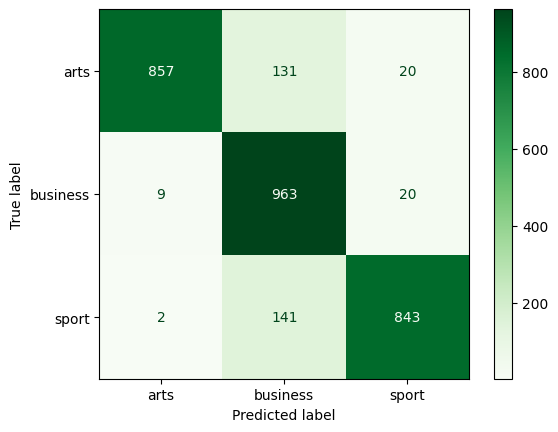

In [6]:
import json
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Download risorse NLTK (solo la prima volta)
nltk.download("punkt")
nltk.download("stopwords")
nltk.download('punkt_tab')

STOP_WORDS = set(stopwords.words("english"))

def load_articles_from_json(path):
    """
    Legge un file JSON e restituisce una lista di articoli
    con category, title e content, filtrando quelli con categoria vuota.
    """
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    articles = []

    for item in data:
        article_category = item.get("category", "").lower() # Convert to lowercase for consistency
        # Only include articles with a non-empty category
        if article_category:
            article = {
                "category": article_category,
                "title": item.get("title", ""),
                "content": item.get("content", "")
            }
            articles.append(article)

    return articles

def get_common_token(all_tokens_list, max_token=20):
  # Appiattiamo la lista di liste in una singola lista di token
  flattened_tokens = [token for sublist in all_tokens_list for token in sublist]

  token_counts = Counter(flattened_tokens)

  # prendi le 10 più frequenti
  top = token_counts.most_common(max_token)

  print("Top 10 parole più frequenti negli articoli:")

  for word, freq in top:
      print(f"{word}: {freq}")
  return top

def count_buzzwords(tokens_article, buzzwords):
    return sum(token in buzzwords for token in tokens_article)

def preprocess_text(text):
    """
    Tokenizza e pulisce il testo:
    - lowercase
    - tokenizzazione
    - rimozione punteggiatura / token non alfabetici
    - rimozione stopwords
    """
    text = text.lower()
    tokens = word_tokenize(text)

    cleaned_tokens = []
    for token in tokens:
        # tiene solo token alfabetici
        if re.fullmatch(r"[a-zA-Z]+", token):
            if token not in STOP_WORDS:
                cleaned_tokens.append(token)

    return cleaned_tokens

def classify_baseline(articles):
  y_true = [article["category"] for article in articles]
  y_pred = [article["prediction"] for article in articles]

  # Ensure labels are explicitly defined for consistency
  labels_present = sorted(list(set(y_true + y_pred)))
  if "" in labels_present: labels_present.remove("") # Remove empty string if present after filtering
  if not labels_present: labels_present = ["sport", "business", "arts"]

  cm = confusion_matrix(y_true, y_pred, labels=labels_present)

  print(cm)
  print(classification_report(y_true, y_pred, labels=labels_present))
  print("Baseline accuracy:", accuracy_score(y_true, y_pred))
  disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=labels_present,
    display_labels=labels_present,
    cmap="Greens"
  )

  plt.show()

# Caricamento dati (Assicurati che i file esistano nel path)
sport_articles = load_articles_from_json("bbc_sport_articles.json")
business_articles = load_articles_from_json("bbc_business_articles.json")
arts_articles = load_articles_from_json("bbc_arts_articles.json")

all_articles = sport_articles + business_articles + arts_articles

baseline_sport_words = ['game', 'league', 'team', 'win', 'season', 'cup', 'players', 'club', 'games', 'football', 'goal', 'player', 'teams']
baseline_business_words = ['trump', 'year', 'people', 'uk', 'company', 'government', 'ai', 'world', 'president', 'china', 'trade', 'iran', 'tariffs', 'india', 'deal']
baseline_arts_words = ['art', 'theatre', 'artist', 'museum', 'artwork', 'show', 'follow', 'exhibition', 'piece', 'meeting', 'artists', 'local']

# Eseguiamo il preprocessing per ogni articolo
for article in all_articles:
    full_text = article["title"] + " " + article["content"]
    tokens = preprocess_text(full_text)
    article['sport_buzzword_count'] = count_buzzwords(tokens, baseline_sport_words)
    article['business_buzzword_count'] = count_buzzwords(tokens, baseline_business_words)
    article['arts_buzzword_count'] = count_buzzwords(tokens, baseline_arts_words)
    counts = {
      'sport': article['sport_buzzword_count'],
      'arts': article['arts_buzzword_count'],
      'business': article['business_buzzword_count']
    }

    article['prediction'] = max(counts, key=counts.get)

classify_baseline(all_articles)

Regressione logistica

Training set size: 2388 articles
Test set size: 598 articles
TF-IDF features for training set: (2388, 54703)
TF-IDF features for test set: (598, 54703)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

        arts       0.99      0.99      0.99       202
    business       0.98      0.98      0.98       199
       sport       0.99      0.99      0.99       197

    accuracy                           0.99       598
   macro avg       0.99      0.99      0.99       598
weighted avg       0.99      0.99      0.99       598

Logistic Regression Accuracy: 0.9899665551839465


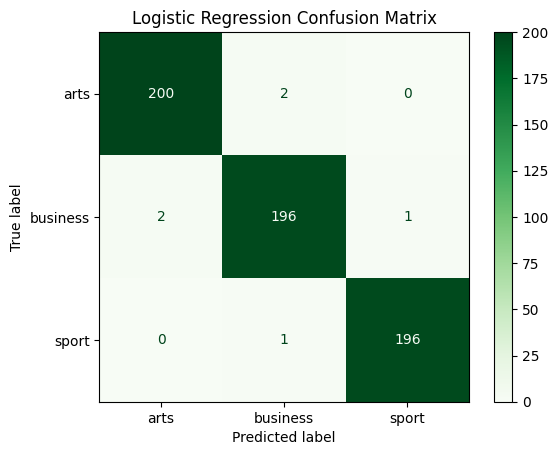

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Combine title and content into a single text field for each article
for article in all_articles:
    article['full_text'] = article['title'] + " " + article['content']

# Prepare data for logistic regression
X = [article['full_text'] for article in all_articles]
y = [article['category'] for article in all_articles]

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} articles")
print(f"Test set size: {len(X_test)} articles")

# Initialize TF-IDF Vectorizer
# min_df ignores terms that appear in too few documents (e.g., 5)
# max_df ignores terms that appear in too many documents (e.g., 90% of documents)
# ngram_range (1,2) means consider unigrams and bigrams
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=100, ngram_range=(1,2))

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF features for training set: {X_train_tfidf.shape}")
print(f"TF-IDF features for test set: {X_test_tfidf.shape}")

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test_tfidf)

# Evaluate the model
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=log_reg_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_model.classes_)
disp.plot(cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Neural network

# Task
Convert the categorical labels in `y_train` and `y_test` to numerical format. Build and train a Keras sequential neural network model for binary classification using the TF-IDF transformed training data. Evaluate the model's performance by generating a classification report, accuracy score, and confusion matrix on the test data. Finally, summarize the neural network's results and compare them to the logistic regression model's performance.

## Prepare Labels for Neural Network

### Subtask:
Convert the categorical labels ('sport', 'business') in `y_train` and `y_test` into numerical format (e.g., 0, 1) suitable for a Keras neural network.


**Reasoning**:
To prepare the categorical labels for a neural network, I need to convert them into numerical format using `LabelEncoder` as specified in the instructions. This will involve importing the encoder, fitting it on the training data, and then transforming both training and test labels.



In [8]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit on y_train and transform y_train
y_train_encoded = label_encoder.fit_transform(y_train)

# Transform y_test using the same fitted encoder
y_test_encoded = label_encoder.transform(y_test)

print("Original y_train labels (first 5):", y_train[:5])
print("Encoded y_train labels (first 5):", y_train_encoded[:5])
print("Original y_test labels (first 5):", y_test[:5])
print("Encoded y_test labels (first 5):", y_test_encoded[:5])
print("Classes detected by LabelEncoder:", label_encoder.classes_)

Original y_train labels (first 5): ['arts', 'arts', 'business', 'business', 'sport']
Encoded y_train labels (first 5): [0 0 1 1 2]
Original y_test labels (first 5): ['arts', 'sport', 'arts', 'business', 'sport']
Encoded y_test labels (first 5): [0 2 0 1 2]
Classes detected by LabelEncoder: ['arts' 'business' 'sport']


**Reasoning**:
Now that the labels are encoded, I need to build and train a Keras sequential neural network model for binary classification using the TF-IDF transformed training data. This involves importing necessary Keras modules, defining the model architecture, compiling it, and then training it.



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     7,002,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,010,433 (26.74 MB)

 Trainable params: 7,010,433 (26.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.5304 - loss: -0.9590 - val_accuracy: 0.6025 - val_loss: -4.8203
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.6183 - loss: -18.1252 - val_accuracy: 0.5272 - val_loss: -39.8451
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - accuracy: 0.6073 - loss: -87.7220 - val_accuracy: 0.5230 - val_loss: -144.0263
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.6052 - loss: -257.9792 - val_accuracy: 0.5126 - val_loss: -366.6398
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.6052 - loss: -581.4935 - val_accuracy: 0.4979 - val_loss: -745.2928
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.6037 - loss: -1103.8148 - val_accuracy: 0.4979 - val_loss: -1338.7694
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.6084 - loss: -1874.7594 - val_accuracy: 0.4937 - val_loss: -2166.7097
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


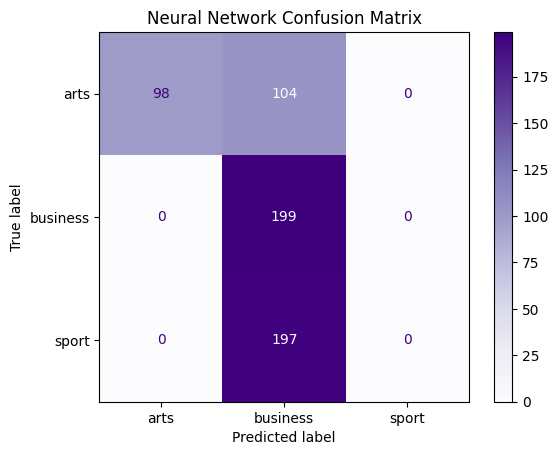

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define the neural network model
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_tfidf.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Train the model
# Convert sparse TF-IDF matrices to dense for Keras, if necessary. For larger datasets, it's better to use methods that handle sparse inputs directly, or convert to a sparse tensor format if Keras supports it.
# For this size, converting to dense is acceptable.
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

history = model.fit(
    X_train_tfidf_dense,
    y_train_encoded,
    epochs=10, # Number of training epochs
    batch_size=32, # Number of samples per gradient update
    validation_split=0.2, # Fraction of the training data to be used as validation data
    verbose=1
)

print("Neural network training complete.")

# Make predictions on the test set
y_pred_proba = model.predict(X_test_tfidf_dense)
y_pred_encoded = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary class (0 or 1)

# Convert encoded predictions back to original labels for reporting
y_pred_labels = label_encoder.inverse_transform(y_pred_encoded.flatten())

print("\nNeural Network Classification Report:")
print(classification_report(y_test, y_pred_labels, target_names=label_encoder.classes_))

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_labels))

# Plot Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_labels, labels=label_encoder.classes_)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=label_encoder.classes_)
disp_nn.plot(cmap="Purples")
plt.title("Neural Network Confusion Matrix")
plt.show()